In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('../data/engineered_data.csv')

X = df.drop(columns=['target'])
y = df['target']

print(f"Features: {X.shape[1]} columns")
print(f"Samples: {X.shape[0]} rows")
print(f"Positive class rate: {y.mean()*100:.1f}%")

Features: 134 columns
Samples: 71518 rows
Positive class rate: 8.8%


In [6]:
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42)
print(f"Train: {X_train.shape[0]} rows")
print(f"Validation: {X_val.shape[0]} rows")
print(f"Test: {X_test.shape[0]} rows")
print(f"\nTrain positive rate: {y_train.mean()*100:.1f}%")
print(f"Val positive rate: {y_val.mean()*100:.1f}%")
print(f"Test positive rate: {y_test.mean()*100:.1f}%")

Train: 50062 rows
Validation: 10728 rows
Test: 10728 rows

Train positive rate: 8.8%
Val positive rate: 8.8%
Test positive rate: 8.8%


In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score

# Scale features for logistic regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

# Train
lr = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)
lr.fit(X_train_scaled, y_train)

# Predict
lr_pred = lr.predict(X_val_scaled)
lr_prob = lr.predict_proba(X_val_scaled)[:, 1]

# Evaluate
print("=== Logistic Regression ===")
print(classification_report(y_val, lr_pred))
print(f"AUC-ROC: {roc_auc_score(y_val, lr_prob):.4f}")

=== Logistic Regression ===
              precision    recall  f1-score   support

           0       0.94      0.63      0.75      9784
           1       0.13      0.55      0.20       944

    accuracy                           0.62     10728
   macro avg       0.53      0.59      0.48     10728
weighted avg       0.86      0.62      0.70     10728

AUC-ROC: 0.6275


In [10]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_val)
rf_prob = rf.predict_proba(X_val)[:, 1]

print("=== Random Forest ===")
print(classification_report(y_val, rf_pred))
print(f"AUC-ROC: {roc_auc_score(y_val, rf_prob):.4f}")

=== Random Forest ===
              precision    recall  f1-score   support

           0       0.91      1.00      0.95      9784
           1       1.00      0.00      0.00       944

    accuracy                           0.91     10728
   macro avg       0.96      0.50      0.48     10728
weighted avg       0.92      0.91      0.87     10728

AUC-ROC: 0.6256


In [12]:
from xgboost import XGBClassifier

neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
scale_ratio = neg_count / pos_count
print(f"Class imbalance ratio: {scale_ratio:.1f}:1")

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale_ratio,
    random_state=42,
    eval_metric='auc',
    use_label_encoder=False
)

xgb.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)

xgb_pred = xgb.predict(X_val)
xgb_prob = xgb.predict_proba(X_val)[:, 1]

print("\n=== XGBoost ===")
print(classification_report(y_val, xgb_pred))
print(f"AUC-ROC: {roc_auc_score(y_val, xgb_prob):.4f}")

Class imbalance ratio: 10.4:1

=== XGBoost ===
              precision    recall  f1-score   support

           0       0.93      0.77      0.84      9784
           1       0.15      0.41      0.22       944

    accuracy                           0.74     10728
   macro avg       0.54      0.59      0.53     10728
weighted avg       0.86      0.74      0.79     10728

AUC-ROC: 0.6323


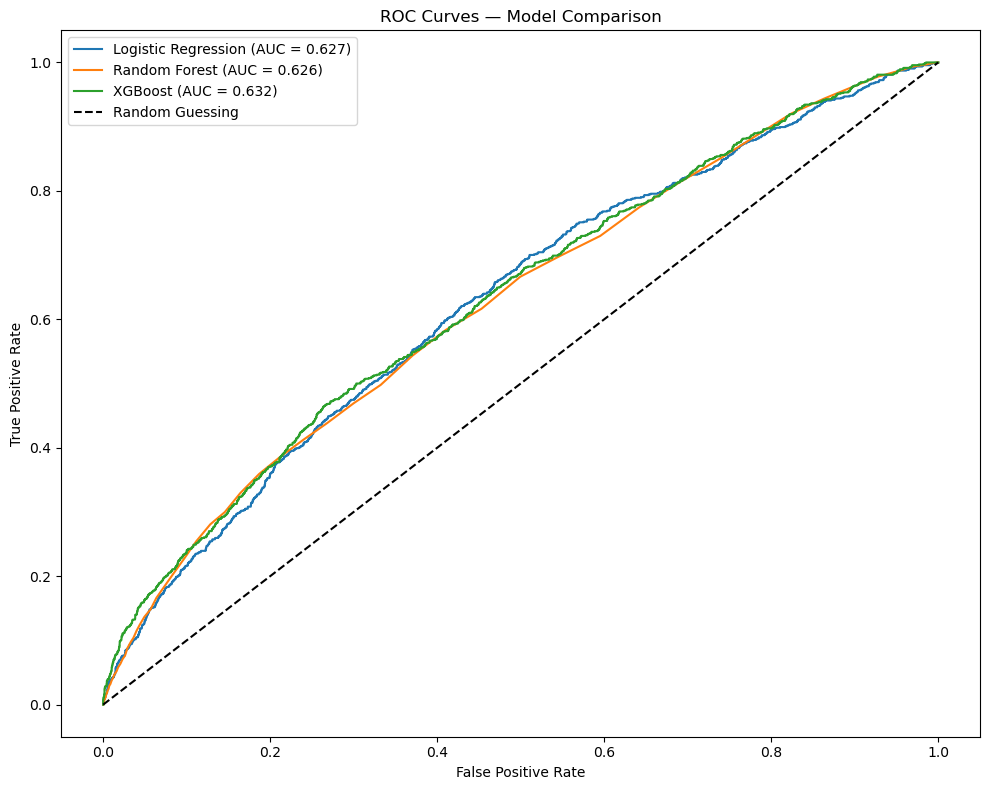

In [14]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

plt.figure(figsize=(10, 8))

for name, probs in [('Logistic Regression', lr_prob),
                     ('Random Forest', rf_prob),
                     ('XGBoost', xgb_prob)]:
    fpr, tpr, _ = roc_curve(y_val, probs)
    auc = roc_auc_score(y_val, probs)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Guessing')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — Model Comparison')
plt.legend()
plt.tight_layout()
plt.savefig('../figures/roc_comparison.png', dpi=150)
plt.show()

In [16]:
from sklearn.model_selection import RandomizedSearchCV

param_distributions = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [3, 4, 5, 6, 7, 8],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    'min_child_weight': [1, 3, 5, 7]
}

search = RandomizedSearchCV(
    XGBClassifier(
        scale_pos_weight=scale_ratio,
        use_label_encoder=False,
        eval_metric='auc',
        random_state=42
    ),
    param_distributions,
    n_iter=50,
    scoring='roc_auc',
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

search.fit(X_train, y_train)

print(f"\nBest parameters: {search.best_params_}")
print(f"Best CV AUC: {search.best_score_:.4f}")

Fitting 5 folds for each of 50 candidates, totalling 250 fits

Best parameters: {'subsample': 0.8, 'n_estimators': 500, 'min_child_weight': 7, 'max_depth': 5, 'learning_rate': 0.01, 'colsample_bytree': 0.7}
Best CV AUC: 0.6529


=== Final Test Results (Tuned XGBoost) ===
              precision    recall  f1-score   support

           0       0.94      0.67      0.78      9784
           1       0.14      0.55      0.22       944

    accuracy                           0.66     10728
   macro avg       0.54      0.61      0.50     10728
weighted avg       0.87      0.66      0.73     10728

AUC-ROC: 0.6626


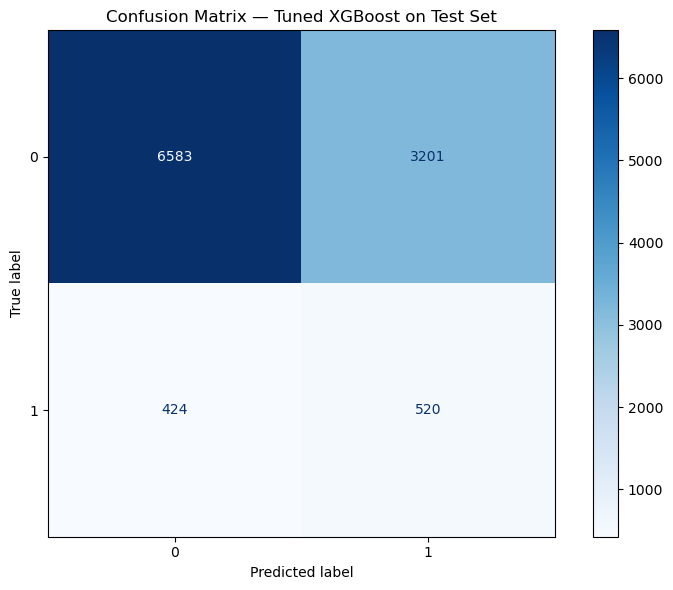

In [18]:
from sklearn.metrics import (classification_report, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay)

best_xgb = search.best_estimator_

test_pred = best_xgb.predict(X_test)
test_prob = best_xgb.predict_proba(X_test)[:, 1]

print("=== Final Test Results (Tuned XGBoost) ===")
print(classification_report(y_test, test_pred))
print(f"AUC-ROC: {roc_auc_score(y_test, test_prob):.4f}")

fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(y_test, test_pred, ax=ax, cmap='Blues')
plt.title('Confusion Matrix — Tuned XGBoost on Test Set')
plt.tight_layout()
plt.savefig('../figures/confusion_matrix.png', dpi=150)
plt.show()

In [20]:
# Increase to 100 iterations with a wider parameter range
param_distributions_v2 = {
    'n_estimators': [300, 500, 700, 1000],
    'max_depth': [3, 4, 5, 6],
    'learning_rate': [0.005, 0.01, 0.02, 0.05],
    'subsample': [0.6, 0.7, 0.8, 0.9],
    'colsample_bytree': [0.5, 0.6, 0.7, 0.8],
    'min_child_weight': [5, 7, 10, 15],
    'gamma': [0, 0.1, 0.3, 0.5],
    'reg_alpha': [0, 0.01, 0.1, 1],
    'reg_lambda': [1, 1.5, 2, 3]
}

search_v2 = RandomizedSearchCV(
    XGBClassifier(
        scale_pos_weight=scale_ratio,
        use_label_encoder=False,
        eval_metric='auc',
        random_state=42
    ),
    param_distributions_v2,
    n_iter=100,
    scoring='roc_auc',
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

search_v2.fit(X_train, y_train)

print(f"\nBest parameters: {search_v2.best_params_}")
print(f"Best CV AUC: {search_v2.best_score_:.4f}")
print(f"Previous best CV AUC: {search.best_score_:.4f}")

Fitting 5 folds for each of 100 candidates, totalling 500 fits

Best parameters: {'subsample': 0.8, 'reg_lambda': 1.5, 'reg_alpha': 1, 'n_estimators': 300, 'min_child_weight': 10, 'max_depth': 6, 'learning_rate': 0.01, 'gamma': 0.5, 'colsample_bytree': 0.5}
Best CV AUC: 0.6558
Previous best CV AUC: 0.6529


In [ ]:
best_xgb_v2 = search_v2.best_estimator_

test_pred_v2 = best_xgb_v2.predict(X_test)
test_prob_v2 = best_xgb_v2.predict_proba(X_test)[:, 1]

print("=== Tuned XGBoost V2 — Test Set ===")
print(classification_report(y_test, test_pred_v2))
print(f"AUC-ROC: {roc_auc_score(y_test, test_prob_v2):.4f}")
print(f"Previous test AUC: 0.6626")
